In [1]:
'''
SOLWA Example7
Layer-by-layer absorption calculation

Demonstrates how to compute the fraction of incident power absorbed in each
layer of a multilayer structure using the Poynting flux method.

Structure (top to bottom):
  Input  : Air (eps = 1)
  Layer 0: aSi square nanopillar in air (absorbing, patterned), 250 nm thick
  Layer 1: SiO2 spacer (non-absorbing, homogeneous), 100 nm thick
  Layer 2: aSi slab (absorbing, homogeneous), 150 nm thick
  Output : Glass substrate (eps = 1.46^2)
'''
# Import
import numpy as np
import torch
from matplotlib import pyplot as plt

import solwa

# Hardware
# If GPU support TF32 tensor core, the matmul operation is faster than FP32 but with less precision.
# If you need accurate operation, you have to disable the flag below.
torch.backends.cuda.matmul.allow_tf32 = False
sim_dtype = torch.complex64
geo_dtype = torch.float32
device = torch.device('cuda')

# Simulation environment
# light
lamb0 = torch.tensor(532., dtype=geo_dtype, device=device)    # nm
inc_ang = 0.*(np.pi/180)    # radian
azi_ang = 0.*(np.pi/180)    # radian

# material
substrate_eps = 1.46**2
sio2_eps = 1.46**2
silicon = solwa.materials.Material("Materials_data/aSiH.txt")
silicon_eps = silicon.apply(lamb0)**2

# geometry
L = [300., 300.]            # nm / nm
solwa.rcwa_geo.dtype = geo_dtype
solwa.rcwa_geo.device = device
solwa.rcwa_geo.Lx = L[0]
solwa.rcwa_geo.Ly = L[1]
solwa.rcwa_geo.nx = 300
solwa.rcwa_geo.ny = 300
solwa.rcwa_geo.grid()
solwa.rcwa_geo.edge_sharpness = 1000.

x_axis = solwa.rcwa_geo.x.cpu()
y_axis = solwa.rcwa_geo.y.cpu()

# layers
# Layer 0: aSi square nanopillar in air (absorbing, patterned), 250 nm thick
layer0_geometry = solwa.rcwa_geo.square(W=150., Cx=L[0]/2., Cy=L[1]/2.)
layer0_eps = layer0_geometry * silicon_eps + (1. - layer0_geometry)
layer0_thickness = 250.
# Layer 1: SiO2 spacer (non-absorbing, homogeneous), 100 nm thick
layer1_eps = sio2_eps
layer1_thickness = 100.
# Layer 2: aSi slab (absorbing, homogeneous), 150 nm thick
layer2_eps = silicon_eps
layer2_thickness = 150.

Layer 1: SiO2 spacer     (homogeneous, eps = 2.1316)
Layer 2: aSi slab        (homogeneous, eps = 12.0116 + 0.5259j)


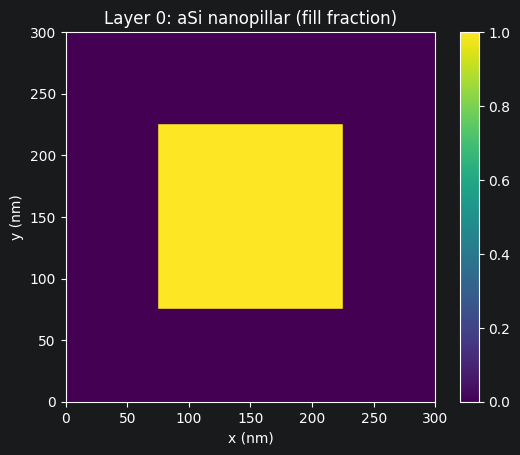

In [2]:
# View layer 0 geometry
plt.imshow(torch.transpose(layer0_geometry, -2, -1).cpu(), origin='lower',
           extent=[x_axis[0], x_axis[-1], y_axis[0], y_axis[-1]])
plt.title('Layer 0: aSi nanopillar (fill fraction)')
plt.xlim([0, L[0]])
plt.xlabel('x (nm)')
plt.ylim([0, L[1]])
plt.ylabel('y (nm)')
plt.colorbar()
print('Layer 1: SiO2 spacer     (homogeneous, eps = {:.4f})'.format(sio2_eps))
print('Layer 2: aSi slab        (homogeneous, eps = {:.4f} + {:.4f}j)'.format(
    silicon_eps.real.item(), silicon_eps.imag.item()))

In [3]:
# Generate and perform simulation
order_N = 10
order = [order_N, order_N]

sim = solwa.rcwa(freq=1/lamb0, order=order, L=L, dtype=sim_dtype, device=device)
sim.add_input_layer(eps=1.)
sim.add_output_layer(eps=substrate_eps)
sim.set_incident_angle(inc_ang=inc_ang, azi_ang=azi_ang)
sim.add_layer(thickness=layer0_thickness, eps=layer0_eps)
sim.add_layer(thickness=layer1_thickness, eps=layer1_eps)
sim.add_layer(thickness=layer2_thickness, eps=layer2_eps)
sim.solve_global_smatrix()

# Set x-polarized unit amplitude plane wave source
sim.source_planewave(amplitude=[1., 0.], direction='forward')

# Incident power: 0.5 * unit_cell_area for unit amplitude x-pol in vacuum at normal incidence
P_inc = 0.5 * L[0] * L[1]

# Layer-by-layer absorption via Poynting flux
# Absorption in layer i = Poynting flux at the top of layer i - Poynting flux at the bottom
# (z_prop=0 is the interface facing the input; z_prop=thickness is the interface facing the output)
layer_thicknesses = [layer0_thickness, layer1_thickness, layer2_thickness]
layer_labels = ['Layer 0 (aSi pillar)', 'Layer 1 (SiO2 spacer)', 'Layer 2 (aSi slab)']
absorptions = []
for i in range(sim.layer_N):
    flux_top = sim.poynting_flux(i, solwa.rcwa_geo.x, solwa.rcwa_geo.y, z_prop=0.)
    flux_bot = sim.poynting_flux(i, solwa.rcwa_geo.x, solwa.rcwa_geo.y, z_prop=layer_thicknesses[i])
    absorptions.append(((flux_top - flux_bot) / P_inc).item())

# Reflection and transmission power (0th order; only order propagating for L < lambda)
R = abs(sim.S_parameters(orders=[0,0], direction='forward', port='reflection',
                          polarization='xx', ref_order=[0,0]).item())**2
T = abs(sim.S_parameters(orders=[0,0], direction='forward', port='transmission',
                          polarization='xx', ref_order=[0,0]).item())**2

# Print energy balance
print('Reflection:                    {:.4f}'.format(R))
for i, (A, lbl) in enumerate(zip(absorptions, layer_labels)):
    print('Absorption in {:s}: {:.4f}'.format(lbl, A))
print('Transmission:                  {:.4f}'.format(T))
print('Sum (energy conservation):     {:.4f}  (should be ~1.0)'.format(
    R + sum(absorptions) + T))

/home/johannes-zeiser/PycharmProjects/solwa/src/solwa/torch_eig.py:46: UserWarning: Aten Op fallback from XPU to CPU happends. This may have performance implications. If need debug the fallback ops please set environment variable `PYTORCH_DEBUG_XPU_FALLBACK=1`  (Triggered internally at /pytorch/build/xpu/ATen/RegisterXPU_0.cpp:54868.)
  eigval, eigvec = torch.linalg.eig(x)


Reflection:                    0.2404
Absorption in Layer 0 (aSi pillar): 0.2525
Absorption in Layer 1 (SiO2 spacer): -0.0016
Absorption in Layer 2 (aSi slab): 0.3690
Transmission:                  0.1330
Sum (energy conservation):     0.9933  (should be ~1.0)


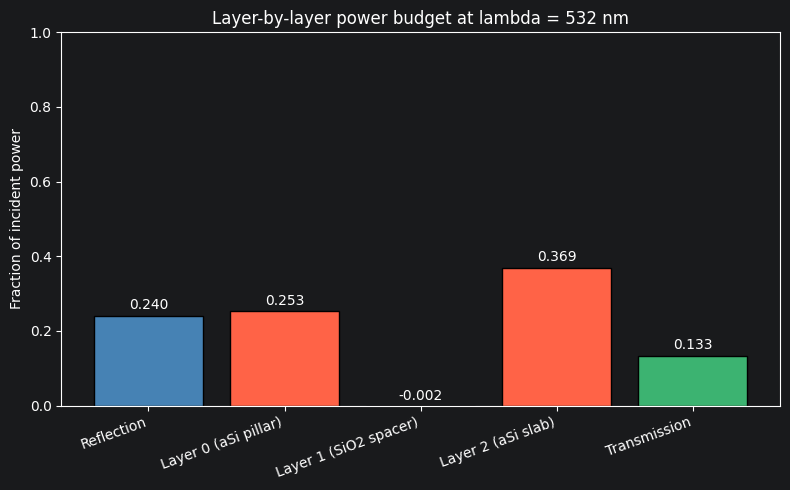

In [4]:
# Plot layer-by-layer power budget
labels = ['Reflection'] + layer_labels + ['Transmission']
values = [R] + absorptions + [T]
colors = ['steelblue', 'tomato', 'lightgray', 'tomato', 'mediumseagreen']

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(labels, values, color=colors, edgecolor='black')
ax.set_ylabel('Fraction of incident power')
ax.set_title('Layer-by-layer power budget at lambda = 532 nm')
ax.set_ylim([0, 1])
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
            '{:.3f}'.format(val), ha='center', va='bottom', fontsize=10)
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()